## Train PDFM

In [1]:
import numpy as np
import configs

import plot_func

import torch
import matplotlib.pyplot as plt

import PD_FM

/cluster/tufts/aeronlab/zhuan01/constrained/PDFM_MDMdataset/plot_func.py:3: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import wasserstein_distance


In [2]:
1

1

In [3]:
import importlib
importlib.reload(plot_func)
importlib.reload(PD_FM)

<module 'PD_FM' from '/cluster/tufts/aeronlab/zhuan01/constrained/PDFM_MDMdataset/PD_FM.py'>

In [4]:
dataname = './dataset/MDMl2ball_dim'+str(configs.d_model)+'.npy'
data = np.load(dataname) #samples

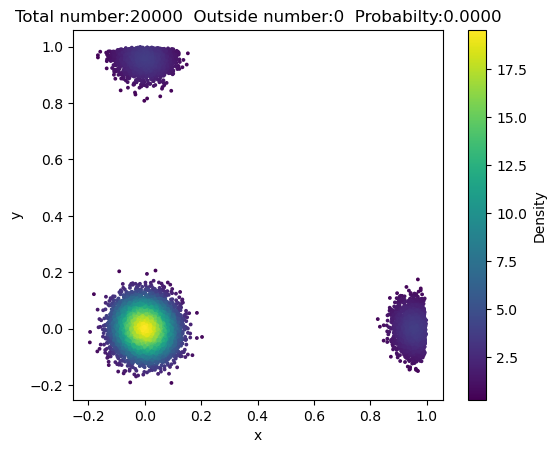

In [5]:
plot_func.plot_scatter_with_info(data[:20000].T, None, '', distance = False)

### Train a regular FM ($\lambda = 0$)

In [ ]:
PD_FM_class = PD_FM.PDFlowMatching()
data_tensor = torch.Tensor(data).to(PD_FM_class.device)
PD_FM_class.train_vanilla(dataset = data_tensor, epoches = 100000, batch_size_N=10000, save_every=50000, lr = 1e-4, save_name = "FM_2uniform", OT = False,)
# PD_FM_class.train_vanilla(dataset = None, epoches = 100000, batch_size_N=10000, save_every=50000, lr = 2e-5, save_name = "OTFM", OT = True,)


### Alg. 2 ($\lambda > 0$)

In [ ]:
PD_FM_class = PD_FM.PDFlowMatching()

data_tensor = torch.Tensor(data).to(PD_FM_class.device)
PD_FM_class.PDFMtrain(data_tensor, max_epoches_per_lambda=3000,batch_size_N = 10000, 
                      lr = 5e-6, init_ckpt_path='./saved_model/FM_l2ball_dim'+str(configs.d_model)+'_iter_1000000.pth', 
                      para_lambda_init = None, target_csrate = 0.9993, PD_lr =800, tval = -1, 
                      update_pmodel_every = 1, OT = False, retrain_pmodel = False, patience = 50, 
                      sample_trajectory=False, p_model_batch_size=2000, save_name="PDFM_2uniform_d"+str(configs.d_model),
                      PD_lr_decay = 1, p_model_lr = 1e-4) #OTFM_100000

## Evaluation 

In [6]:
import numpy as np


import plot_func

import torch
import matplotlib.pyplot as plt
import configs

import PD_FM

In [7]:
dataname = './dataset/MDMl2ball_dim'+str(configs.d_model)+'.npy'
data = np.load(dataname) #samples

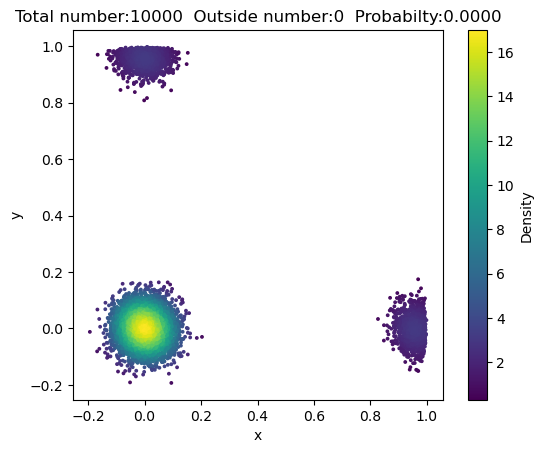

In [8]:
plot_func.plot_scatter_with_info(data[:10000].T, None, '', distance = False)

0.4855515956878662


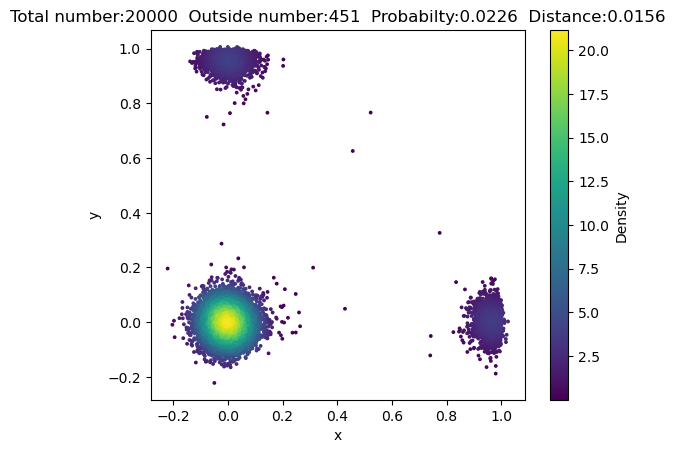

In [9]:
PD_FM_class = PD_FM.PDFlowMatching()
ckpt = torch.load('./saved_model/FM_l2ball_dim'+str(configs.d_model)+'_iter_1000000.pth', weights_only=True)
PD_FM_class.model.load_state_dict(ckpt)


import time
start = time.time()

res = PD_FM_class.sampler(20000).cpu().numpy()

end = time.time()
print(end - start)
plot_func.plot_scatter_with_info(res[:20000].T, data[:20000], '', distance = True)


0.03460240364074707


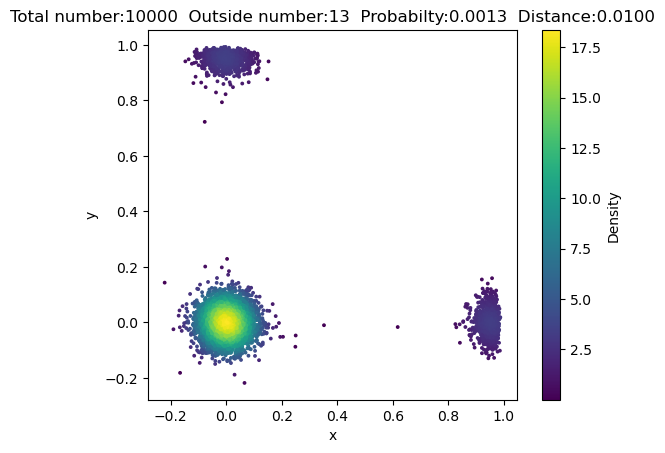

In [13]:
PD_FM_class = PD_FM.PDFlowMatching()
# ckpt = torch.load('./saved_model/PDFM_2uniform_d'+str(configs.d_model)+'/PDFM_2uniform_8_45p78.pth', weights_only=True)
ckpt = torch.load('./saved_model/PDFM_2uniform_d'+str(configs.d_model)+'/PDFM_2uniform_d8_7_21p39.pth', weights_only=True)

PD_FM_class.model.load_state_dict(ckpt)


import time
start = time.time()

res = PD_FM_class.sampler(10000).cpu().numpy()

end = time.time()
print(end - start)
plot_func.plot_scatter_with_info(res.T, data[:10000], '', distance = True)


In [ ]:
FMnum_out_record = np.array([])
FMprob_record = np.array([])
FMSWD_record = np.array([])
PDFMnum_out_record = np.array([])
PDFMprob_record = np.array([])
PDFMSWD_record = np.array([])

for i in range(100):
    if i%10 == 0:
        print(i)
    reference = PD_FM_class.get_samples(data, 10000)


    resPDFM = PD_FM_class.sampler(10000).cpu().numpy()
    PDFMnum_out, PDFMprob, PDFMSWD = plot_func.only_info(resPDFM.transpose(), reference)
    

    PDFMnum_out_record = np.append(PDFMnum_out_record, PDFMnum_out)
    PDFMprob_record = np.append(PDFMprob_record, PDFMprob)
    PDFMSWD_record = np.append(PDFMSWD_record, PDFMSWD)

In [ ]:
print("PDFM SWD: ", f"{np.mean(PDFMSWD_record):.4f}", r"\pm", f"{np.std(PDFMSWD_record):.4f}")
print("PDFM num out: ", f"{np.mean(PDFMnum_out_record):.4f}", r"\pm", f"{np.std(PDFMnum_out_record):.4f}")